# Practice 2: Data Preparation

## Load and transform CIFAR-10 for transfer learning

Load CIFAR-10, apply ImageNet-compatible transforms (Resize(224), Normalize, train-only augmentation), and create DataLoaders. The train/val split is generated once and persisted to data/processed/cifar10_split_seed42.json so every phase uses the same split.

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Imports and configuration | Import load_cifar10 utilities | `src/data/load_cifar10` |
| 2 | Load DataLoaders | Call get_cifar10_loaders() with default params | `src/data/load_cifar10` |
| 3 | Inspect split sizes | Print train/val/test counts | — |
| 4 | Raw sample images | Show original 32x32 CIFAR-10 examples | `torchvision.datasets.CIFAR10` |
| 5 | Transformed sample images | Show 224x224 normalized images from loader | — |
| 6 | Class distribution | Verify label balance across splits | — |
| 7 | Split file confirmation | Confirm JSON was created/loaded | — |

---


In [1]:
# Imports and loaders
import sys, os, json, torch
import matplotlib.pyplot as plt
import numpy as np

# Add project root to path
sys.path.insert(0, os.path.abspath(".."))

from src.data.load_cifar10 import (
    get_cifar10_loaders, SPLIT_FILE,
    IMAGENET_MEAN, IMAGENET_STD,
)

train_loader, val_loader, test_loader = get_cifar10_loaders(
    batch_size=64, num_workers=2
)
print("DataLoaders created successfully")


DataLoaders created successfully


In [3]:
# Inspect split sizes
with open(SPLIT_FILE) as f:
    split = json.load(f)

print("Split file: {}".format(SPLIT_FILE))
print("Seed:       {}".format(split["seed"]))
print("Train/val ratio: {}".format(split["train_ratio"]))
print("Train indices:   {}".format(len(split["train_indices"])))
print("Val indices:     {}".format(len(split["val_indices"])))
print("Test indices:    {}".format(len(split["test_indices"])))


Split file: C:\document\Study documents\Deeplearning_Course\data\processed\cifar10_split_seed42.json
Seed:       42
Train/val ratio: 0.9
Train indices:   45000
Val indices:     5000
Test indices:    10000


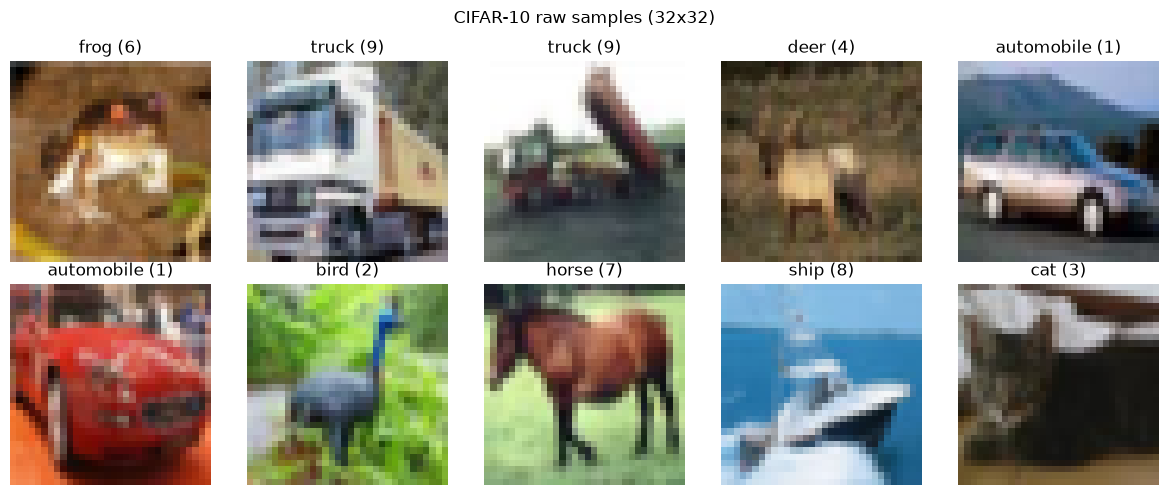

In [5]:
# Raw 32x32 CIFAR-10 samples (pre-transform)
import torchvision

cifar10_raw = torchvision.datasets.CIFAR10(
    root="../data/raw", train=True, transform=None, download=False
)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = cifar10_raw[i]
    ax.imshow(img)
    ax.set_title(f"{CIFAR10_CLASSES[label]} ({label})")
    ax.axis("off")
fig.suptitle("CIFAR-10 raw samples (32x32)")
plt.tight_layout()
plt.show()


Batch shape: torch.Size([64, 3, 224, 224])
Label range: 0..9


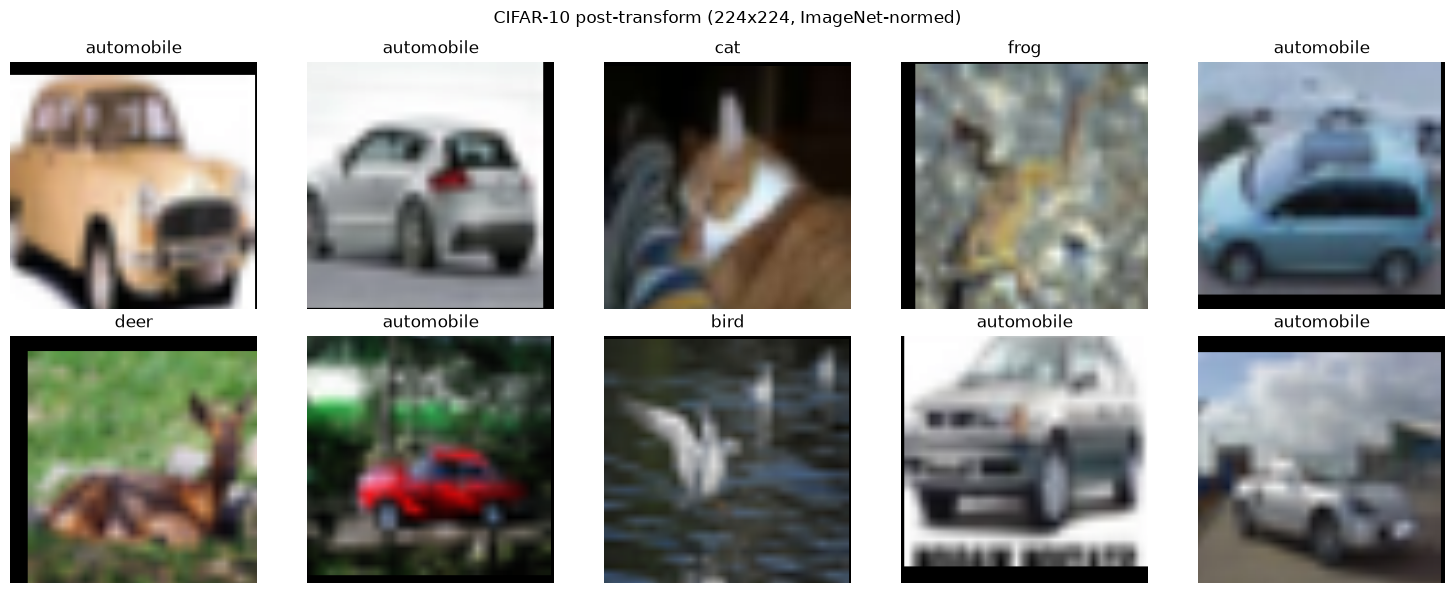

In [6]:
# Transformed 224x224 images (post-transform)
def denormalize(tensor, mean, std):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return tensor * std + mean

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")
print(f"Label range: {labels.min().item()}..{labels.max().item()}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i], IMAGENET_MEAN, IMAGENET_STD)
    img = torch.clamp(img, 0, 1)
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"{CIFAR10_CLASSES[labels[i].item()]}")
    ax.axis("off")
fig.suptitle("CIFAR-10 post-transform (224x224, ImageNet-normed)")
plt.tight_layout()
plt.show()


In [7]:
# Class distribution (train loader, first 10 batches)
from collections import Counter

label_counter = Counter()
for batch_idx, (_, labels) in enumerate(train_loader):
    label_counter.update(labels.tolist())
    if batch_idx >= 9:
        break

total = sum(label_counter.values())
print(f"Labels from {batch_idx+1} batches ({total} samples):")
for cls_id in range(10):
    cnt = label_counter[cls_id]
    pct = 100 * cnt / total
    print(f"  {cls_id} ({CIFAR10_CLASSES[cls_id]:>10}): {cnt:4d} ({pct:.1f}%)")


Labels from 10 batches (640 samples):
  0 (  airplane):   70 (10.9%)
  1 (automobile):   71 (11.1%)
  2 (      bird):   61 (9.5%)
  3 (       cat):   73 (11.4%)
  4 (      deer):   60 (9.4%)
  5 (       dog):   67 (10.5%)
  6 (      frog):   56 (8.8%)
  7 (     horse):   52 (8.1%)
  8 (      ship):   60 (9.4%)
  9 (     truck):   70 (10.9%)


In [8]:
# Confirm split file is persisted
assert os.path.exists(SPLIT_FILE), f"Split file not found: {SPLIT_FILE}"
print(f"Split file confirmed: {SPLIT_FILE}")
print(f"Size: {os.path.getsize(SPLIT_FILE):,} bytes")


Split file confirmed: C:\document\Study documents\Deeplearning_Course\data\processed\cifar10_split_seed42.json
Size: 697,899 bytes
